In [1]:
import pandas as pd
import numpy as np
import warnings as wr
wr.filterwarnings(action='ignore')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
#이미지를 읽어 들이기 위한 라이브러리 추가
import matplotlib.image as mpimg
import matplotlib as mpl
from PIL import Image
import seaborn as sns
import os
font_list = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
#한글처리 -> 코랩에서는 별도로 다시 강의 
plt.rcParams['font.family'] ="NanumGothic"
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split, cross_val_score
#set_printoptions() , numpy에서 지수표기를 해제하려고 할때 사용하는 설정이다.
# 소수점 이하 2자리까지만 표시하겠다 - 맨 상단에 
np.set_printoptions(suppress=True,precision=2)

In [2]:
# konlpy 설치후 모듈 불러오기
from konlpy.tag import Okt, Kkma

In [3]:
t = Okt()
t.pos("안녕 반가워 오늘도 열심히 공부합시다.")

[('안녕', 'Noun'),
 ('반가워', 'Adjective'),
 ('오늘', 'Noun'),
 ('도', 'Josa'),
 ('열심히', 'Adverb'),
 ('공부', 'Noun'),
 ('합시다', 'Verb'),
 ('.', 'Punctuation')]

In [5]:
#norm : 가신닼ㅋ => 가신다 처럼 변환
print(t.pos("아버지가 방에 들어가신닼ㅋ",norm=True))

[('아버지', 'Noun'), ('가', 'Josa'), ('방', 'Noun'), ('에', 'Josa'), ('들어가신다', 'Verb'), ('ㅋ', 'KoreanParticle')]


In [6]:
#stem : 원형을 찾아주는 옵션 : (그래요 => 그렇다)
print(t.pos("아버지가 방에 들어가신닼ㅋ",norm=True , stem=True))

[('아버지', 'Noun'), ('가', 'Josa'), ('방', 'Noun'), ('에', 'Josa'), ('들어가다', 'Verb'), ('ㅋ', 'KoreanParticle')]


In [9]:
print(t.pos('맞아욬ㅋ?'))
print(t.pos('맞아욬ㅋ?', norm=True))
print(t.pos('맞아욬ㅋ?', stem=True, norm=True))

[('맞아욬', 'Noun'), ('ㅋ', 'KoreanParticle'), ('?', 'Punctuation')]
[('맞아요', 'Verb'), ('ㅋ', 'KoreanParticle'), ('?', 'Punctuation')]
[('맞다', 'Verb'), ('ㅋ', 'KoreanParticle'), ('?', 'Punctuation')]


## 말뭉치(corpus)
- 말뭉치(corpus)는 자연어 분석 작업을 위해 만든 샘플 문서의 집합
- 대한민국 헌법 말뭉치
- KoNLPy에서는 대한민국 헌법 말뭉치인 kolaw와 국회법안 말뭉치인 kobill을 제공

In [10]:
from konlpy.corpus import kolaw  #대한민국 헌법 말뭉치
from konlpy.utils import concordance

In [12]:
type(kolaw) , kolaw.fileids()

(konlpy.corpus.CorpusLoader, ['constitution.txt'])

In [13]:
c = kolaw.open(kolaw.fileids()[0]).read()
c[:50] , len(c)

('대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임', 18884)

In [16]:
# konlpy.utils.concordance (찾을단어, 전체문장,show=False)
# show =False  index 위치만
fword = concordance('민주',c,show=True)
fword

13	법통과 불의에 항거한 4·19민주이념을 계승하고, 조국의
16	4·19민주이념을 계승하고, 조국의 민주개혁과 평화적 통일의
35	자율과 조화를 바탕으로 자유민주적 기본질서를 더욱
99	제1조 ① 대한민국은 민주공화국이다. ②대한민국의 주권은
136	대한민국은 통일을 지향하며, 자유민주적 기본질서에 입각한
219	그 목적·조직과 활동이 민주적이어야 하며, 국민의
251	④정당의 목적이나 활동이 민주적 기본질서에 위배될
1026	의무의 내용과 조건을 민주주의원칙에 따라 법률로
2850	자문에 응하기 위하여 민주평화통일자문회의를 둘 수
2854	둘 수 있다. ②민주평화통일자문회의의 조직·직무범위 기타
3649	조화를 통한 경제의 민주화를 위하여 경제에


[13, 16, 35, 99, 136, 219, 251, 1026, 2850, 2854, 3649]

In [17]:
from konlpy.tag import Hannanum,Okt,Kkma,Komoran
hannanum = Hannanum()
kkma = Kkma()
okt = Okt() #인터넷 커뮤니티 용어
komoran = Komoran() 

In [18]:
c[:40]

'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로'

In [19]:
# nouns 명사만 추출한다.
print(f'Hannanum = {hannanum.nouns(c[:40])}')
print(f'Kkma = {kkma.nouns(c[:40])}')
print(f'Komoran = {komoran.nouns(c[:40])}')
print(f'Okt = {okt.nouns(c[:40])}')

Hannanum = ['대한민국헌법', '유구', '역사', '전통', '빛', '우리', '대한국민', '3·1운동']
Kkma = ['대한', '대한민국', '대한민국헌법', '민국', '헌법', '유구', '역사', '전통', '우리', '국민', '3', '1', '1운동', '운동']
Komoran = ['대한민국', '헌법', '역사', '전통', '국민', '운동']
Okt = ['대한민국', '헌법', '유구', '역사', '전통', '우리', '국민', '운동']


In [21]:
# 문장 단위로 검색
word = "반갑습니다. 오늘은 텍스트 분석 수업입니다. 재미있네요!~~"
word_sentence = kkma.sentences(word)
print(f'Sentence => {word_sentence}')
print('kkma noun =>',kkma.nouns(word))  # 명사  noun()
print(f'kkma pos =>{kkma.pos(word)}')  # 태깅별로 제어가 가능하고
print('kkma morphs =>',kkma.morphs(word)) # 값만 
print("*"*30)
# 위의 코드를 한나눔으로 변경 하기
print(f'hannanum nouns => {hannanum.nouns(word)}' )
print(f'hannanum pos =>{hannanum.pos(word)}' )
print(f'hannanum morphs =>{hannanum.morphs(word)}')
print("*"*30)
# okt : nouns, morphs, pos
print(okt.nouns(word))
print(okt.morphs(word))
print(okt.pos(word))
print("*"*30)
word2 = "정말 재미가 있네욬ㅋㅋㅋㅋㅋ 이제 정말로 된나옇ㅎㅎㅎ?"
print(okt.pos(word2,norm=True))
# stem -True이면 토큰을 줄이기. 있네요 -> 있다, 된나여 -> 되다.
print(okt.pos(word2, norm=True,stem=True))
# join -True이면 결합 된 모프 및 태그 집합을 리스트로 반환
print(okt.pos(word2, norm=True,stem=True,join=True))

Sentence => ['반갑습니다.', '오늘은 텍스트 분석 수업입니다.', '재미있네요!~~']
kkma noun => ['오늘', '텍스트', '분석', '수업']
kkma pos =>[('반갑', 'VA'), ('습니다', 'EFN'), ('.', 'SF'), ('오늘', 'NNG'), ('은', 'JX'), ('텍스트', 'NNG'), ('분석', 'NNG'), ('수업', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EFN'), ('.', 'SF'), ('재미있', 'VA'), ('네요', 'EFN'), ('!', 'SF'), ('~~', 'SW')]
kkma morphs => ['반갑', '습니다', '.', '오늘', '은', '텍스트', '분석', '수업', '이', 'ㅂ니다', '.', '재미있', '네요', '!', '~~']
******************************
hannanum nouns => ['오늘', '텍스트', '분석', '수업']
hannanum pos =>[('반갑', 'P'), ('습니다', 'E'), ('.', 'S'), ('오늘', 'N'), ('은', 'J'), ('텍스트', 'N'), ('분석', 'N'), ('수업', 'N'), ('이', 'J'), ('ㅂ니다', 'E'), ('.', 'S'), ('재미있', 'P'), ('네', 'E'), ('요', 'J'), ('!', 'S'), ('~~', 'S')]
hannanum morphs =>['반갑', '습니다', '.', '오늘', '은', '텍스트', '분석', '수업', '이', 'ㅂ니다', '.', '재미있', '네', '요', '!', '~~']
******************************
['오늘', '텍스트', '분석', '수업']
['반갑습니다', '.', '오늘', '은', '텍스트', '분석', '수업', '입니다', '.', '재미있네요', '!~~']
[('반갑습니다', 'Adjective'), ('.', 'P

In [ ]:
# nltk, konlpy -> 형태소 추출(명사, 동사, 형용사......)

In [23]:
#!pip install nltk

In [24]:
from nltk import Text

In [42]:
# 헌법 말뭉치에서 okt를 가지고 명사만 추출!
okt.nouns(c)

['대한민국',
 '헌법',
 '유구',
 '역사',
 '전통',
 '우리',
 '국민',
 '운동',
 '건립',
 '대한민국',
 '임시정부',
 '법',
 '통과',
 '불의',
 '항거',
 '민주',
 '이념',
 '계승',
 '조국',
 '민주',
 '개혁',
 '평화',
 '통일',
 '사명',
 '입',
 '각하',
 '정의',
 '인도',
 '동포',
 '애',
 '로써',
 '민족',
 '단결',
 '공고',
 '모든',
 '사회',
 '폐습',
 '불의',
 '타파',
 '자율',
 '조화',
 '바탕',
 '자유민주',
 '질서',
 '더욱',
 '정치',
 '경제',
 '사회',
 '문화',
 '모든',
 '영역',
 '각인',
 '기회',
 '능력',
 '최고',
 '도로',
 '발휘',
 '자유',
 '권리',
 '책임',
 '의무',
 '완수',
 '안',
 '국민',
 '생활',
 '향상',
 '기하',
 '밖',
 '항구',
 '세계',
 '평화',
 '인류',
 '공영',
 '이바지',
 '함',
 '우리',
 '우리',
 '자손',
 '안전',
 '자유',
 '행복',
 '확보',
 '것',
 '다짐',
 '제정',
 '차',
 '개정',
 '헌법',
 '이제',
 '국회',
 '의결',
 '국민투표',
 '개정',
 '제',
 '장',
 '강',
 '제',
 '대한민국',
 '민주공화국',
 '대한민국',
 '주권',
 '국민',
 '모든',
 '권력',
 '국민',
 '제',
 '대한민국',
 '국민',
 '요건',
 '법률',
 '정',
 '국가',
 '법률',
 '정',
 '바',
 '재외국민',
 '보호',
 '의무',
 '제',
 '대한민국',
 '영토',
 '한반도',
 '그',
 '부속',
 '도서',
 '제',
 '대한민국',
 '통일',
 '지향',
 '자유민주',
 '질서',
 '입각',
 '평화',
 '통일',
 '정책',
 '수립',
 '추진',
 '제',
 '대한민국',
 '국제',
 '평화',
 '

In [27]:
print(f'추출한 명사들의 길이:{len(okt.nouns(c))}')

추출한 명사들의 길이:3882


Okt가 추출한 명사들의 카운트 :<FreqDist with 929 samples and 3882 outcomes>
Token의 단어의 갯수 :3882


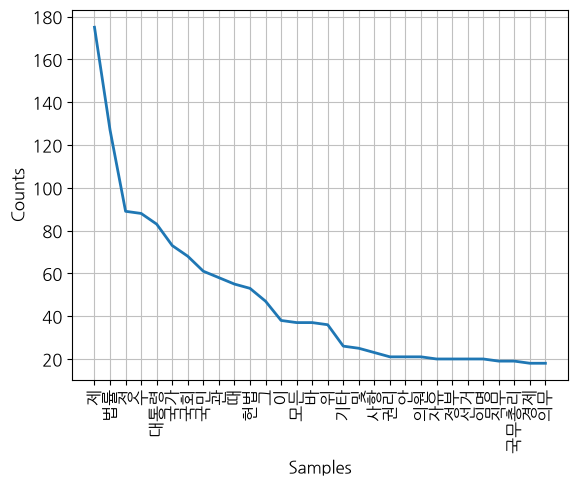

In [32]:
# 형태소 - 명사 추출을 통한 토큰화 된 것 에 대해서 Text객체를 생성해서 count
kolaw = Text(okt.nouns(c),name="Kolaw")
type(kolaw) #nltk.text.Text
# kolaw.vocab() 각각의 명사 - okt.nouns(c)에 대해서 카운트를 한다.
print(f"Okt가 추출한 명사들의 카운트 :{kolaw.vocab()}")
print(f"Token의 단어의 갯수 :{len(kolaw.tokens)}")
#30개만 시각화 진행 
kolaw.plot(30)
plt.show()

In [33]:
kolaw.vocab()

FreqDist({'제': 175, '법률': 127, '정': 89, '수': 88, '대통령': 83, '국가': 73, '국회': 68, '국민': 61, '관': 58, '때': 55, ...})

In [34]:
font_path = font_list[1]
font_path

'NanumGothic'

In [36]:
#!pip install wordcloud

In [37]:
from wordcloud import WordCloud

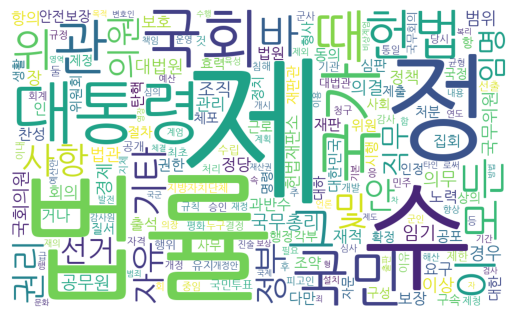

In [41]:
wc = WordCloud(width=1000,height=600,background_color='white',font_path=font_path)
plt.imshow(wc.generate_from_frequencies(kolaw.vocab()))
plt.axis('off')
plt.show()

In [43]:
kolaw.vocab()

FreqDist({'제': 175, '법률': 127, '정': 89, '수': 88, '대통령': 83, '국가': 73, '국회': 68, '국민': 61, '관': 58, '때': 55, ...})

In [68]:
# 불용어 : 예를  명사임에도 불구하고 학습에 필요없는 데이터를 의미 
stop_words = ['제','정','수','관','때','로써','모든','및','입','애','그','이','바','위','안','기타']

In [69]:
tokens_ko = okt.nouns(c)
ko = Text(tokens_ko,name='kolaw')
ko.vocab()

FreqDist({'제': 175, '법률': 127, '정': 89, '수': 88, '대통령': 83, '국가': 73, '국회': 68, '국민': 61, '관': 58, '때': 55, ...})

In [70]:
# stop_words list안에 존재하지 않는 x값만 컴프리헨션 리스트로 추출
kov = [x for x in ko if x not in stop_words]
print(kov[:10])

['대한민국', '헌법', '유구', '역사', '전통', '우리', '국민', '운동', '건립', '대한민국']


In [71]:
tokens_ko = okt.nouns(c)
ko2 = Text(tokens_ko,name='kolaw')
ko3 = []
for tag in ko2:
    if tag not in stop_words:
        ko3.append(tag)
print(ko3[:10])

['대한민국', '헌법', '유구', '역사', '전통', '우리', '국민', '운동', '건립', '대한민국']


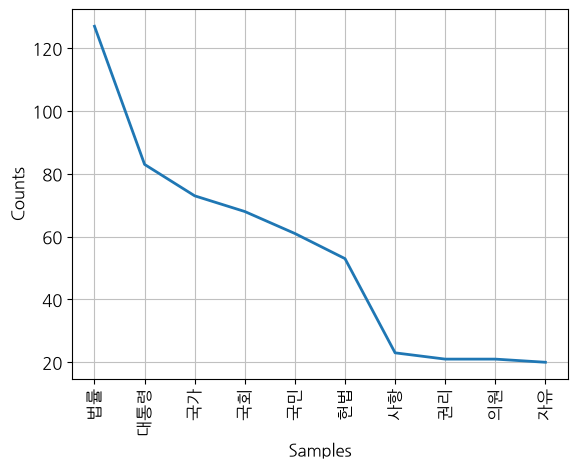

In [72]:
# 다시 불용어가 처리된 단어를 기반으로 카운트를 시각화 시키기
kolaw = Text(kov,name="kolaw")
kolaw.plot(10)
plt.show()

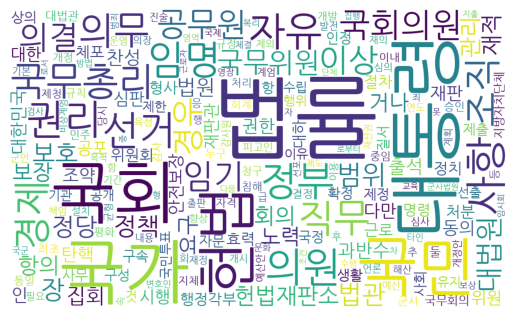

In [73]:
wc = WordCloud(width=1000,height=600,background_color='white',font_path=font_path)
plt.imshow(wc.generate_from_frequencies(kolaw.vocab()))
plt.axis('off')
plt.show()

In [76]:
#os.listdir('dataset')

shape:(612, 612, 3)
ndim:3


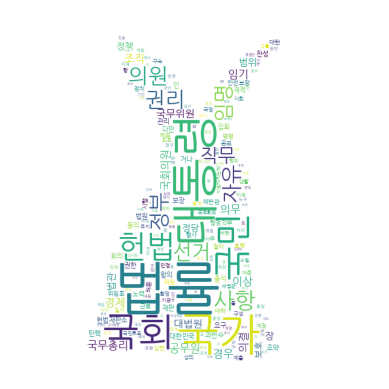

In [86]:
images = 'dataset/rabbit.jpg'
mypororo_mask =  np.array(Image.open(images))
print(f'shape:{mypororo_mask.shape}')
print(f'ndim:{mypororo_mask.ndim}')
wc = WordCloud(width=1000,height=600, background_color='white',
              font_path=font_path, mask=mypororo_mask)
plt.imshow(wc.generate_from_frequencies(kolaw.vocab()))
plt.axis('off')
plt.show()

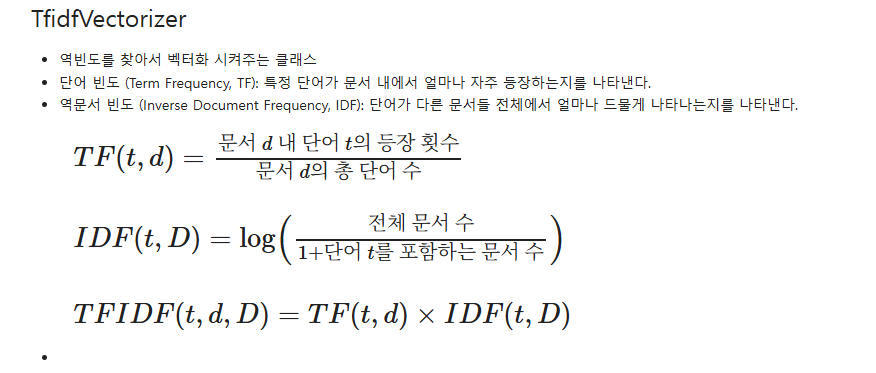

In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer
from numpy.linalg import norm

In [88]:
# 임의의 데이터로 TF-IDF 벡터화 , 코사인 유사도
# 임의의 데이터 생성하기
# list를 하나의 항목 -> 문서 취급으로 해보자.
docs=['저는 자바 좋아요','저는 파이썬 좋아요','저는 파이썬 좋아요 저는 파이썬 좋아요']
docs

['저는 자바 좋아요', '저는 파이썬 좋아요', '저는 파이썬 좋아요 저는 파이썬 좋아요']

In [89]:
# 전처리)
# 구간화 : docs -> 하나의 요소는 String => 저는 자바 좋아요.split()
# => ['저는','자바','좋아요'] => 중복을 제거해서 추출한다음에 => 새로운 리스트에  저장하면 끝
for w in docs:
    print(w.split())

['저는', '자바', '좋아요']
['저는', '파이썬', '좋아요']
['저는', '파이썬', '좋아요', '저는', '파이썬', '좋아요']


In [93]:
# #['저는', '파이썬', '자바', '좋아요']
# for w in docs:
#     #print(w.split())
#     x = 0
#     for ww in w:
#         print(f"{w} : {ww}")
#         x = x + 1
list(set( w for doc in docs for w in doc.split()))

['자바', '저는', '파이썬', '좋아요']

In [94]:
# test2 단어의 빈도 출력 해보기
strv = " ".join(['저는', '파이썬', '좋아요', '저는', '파이썬', '좋아요','룰루랄라','좋아요'])
strv.count('좋아요')

3

In [95]:
vocab = list(set( w for doc in docs for w in doc.split()))
vocab

['자바', '저는', '파이썬', '좋아요']

In [96]:
docs

['저는 자바 좋아요', '저는 파이썬 좋아요', '저는 파이썬 좋아요 저는 파이썬 좋아요']

In [104]:
# 단어들의 행렬을 저장하기 위해서 2중 리스트로 만들어서 사용
result = []
for i in range(len(docs)):
    print(f"{i} => {docs[i]}")
    result.append([])
    print("*"*30)
    d = docs[i]
    for j in range(len(vocab)):
        #print(f"vocab : {vocab[j]}")
        t = vocab[j]
        #비교하면서 count() 사용해서 vocab[j] 즉 t의 단어 카운팅을 하겠다.
        print(f"{d}[{t}] : {d.count(t)}")
        result[-1].append(d.count(t))
print("="*30)
print("단어 행렬의 완성 => result")
print(result)

0 => 저는 자바 좋아요
******************************
저는 자바 좋아요[자바] : 1
저는 자바 좋아요[저는] : 1
저는 자바 좋아요[파이썬] : 0
저는 자바 좋아요[좋아요] : 1
1 => 저는 파이썬 좋아요
******************************
저는 파이썬 좋아요[자바] : 0
저는 파이썬 좋아요[저는] : 1
저는 파이썬 좋아요[파이썬] : 1
저는 파이썬 좋아요[좋아요] : 1
2 => 저는 파이썬 좋아요 저는 파이썬 좋아요
******************************
저는 파이썬 좋아요 저는 파이썬 좋아요[자바] : 0
저는 파이썬 좋아요 저는 파이썬 좋아요[저는] : 2
저는 파이썬 좋아요 저는 파이썬 좋아요[파이썬] : 2
저는 파이썬 좋아요 저는 파이썬 좋아요[좋아요] : 2
단어 행렬의 완성 => result
[[1, 1, 0, 1], [0, 1, 1, 1], [0, 2, 2, 2]]


In [101]:
result

[[], [], []]

In [105]:
# 유사도 구하기 
# -1 <= cos(A,B0 <= 1) 구간이다.
# 유사도 값이 1(높다) 벡터의 방향이 비슷하다. , -1 멀다
# 유사도 0 : 상관관계가 없다.
# A,B의 유사도 공식 함수로 정의 - numpy
def cos_sim(A,B):
    return np.dot(A,B) / (norm(A) * norm(B))

In [108]:
print(np.array(result))
print(np.array(result).shape)
print(np.array(result).ndim)

[[1 1 0 1]
 [0 1 1 1]
 [0 2 2 2]]
(3, 4)
2


In [109]:
vocab

['자바', '저는', '파이썬', '좋아요']

In [111]:
docs

['저는 자바 좋아요', '저는 파이썬 좋아요', '저는 파이썬 좋아요 저는 파이썬 좋아요']

In [110]:
# dataFrame으로 확인 
tf_data = pd.DataFrame(np.array(result),columns=vocab)
tf_data

,자바,저는,파이썬,좋아요
0,1,1,0,1
1,0,1,1,1
2,0,2,2,2


In [114]:
#doc문서 변수로 지정해서 numpy로각각 저장
doc1 = tf_data.loc[0].values
doc2 = tf_data.loc[1].values
doc3 = tf_data.loc[2].values

In [116]:
print(f"dic1 , doc2 => {cos_sim(doc1,doc2)}")   # 저는 자바 좋아요:저는 파이썬 좋아요
print(f"dic1 , doc3 => {cos_sim(doc1,doc3)}") # 저는 자바 좋아요:저는 파이썬 좋아요 저는 파이썬 좋아요
print(f"dic2 , doc3 => {cos_sim(doc2,doc3)}") # 저는 파이썬 좋아요:저는 파이썬 좋아요 저는 파이썬 좋아요

dic1 , doc2 => 0.6666666666666667
dic1 , doc3 => 0.6666666666666667
dic2 , doc3 => 1.0000000000000002


In [122]:
docs=['저는 자바 좋아요','저는 파이썬 좋아요','저는 파이썬 좋아요 저는 파이썬 좋아요']
docs
vocab = list(set(w for doc in docs for w in doc.split()))
vocab.sort()
vocab

['자바', '저는', '좋아요', '파이썬']

In [126]:
from math import log

In [127]:
N = len(docs)
# 단어 빈도 : TF 
def tf(t, d):
  #d문서에서 얼마나 t가 많이 등장하냐 
  return d.count(t)
# 역문서 빈도 : IDF
# 흔하게 나오는 단어가 있으면 가중치를 낮추는 공식 
def idf(t):
  df = 0
  for doc in docs:
    df += t in doc
  return log(N/(df+1)) # +1 더해서 분모가 0이 되는것을 방지 
# TF-IDF 
def tfidf(t, d):
  return tf(t,d)* idf(t)
result = []
# 각 문서에 대해서 아래 연산을 반복
for i in range(N):
  result.append([])
  d = docs[i]
  for j in range(len(vocab)):
    t = vocab[j]
    result[-1].append(tf(t, d))

tf_ = pd.DataFrame(result, columns = vocab)
tf_

,자바,저는,좋아요,파이썬
0,1,1,1,0
1,0,1,1,1
2,0,2,2,2


In [128]:
result = []
for j in range(len(vocab)):
    t = vocab[j]
    result.append(idf(t))
idf_ = pd.DataFrame(result, index=vocab, columns=["IDF"])
idf_

,IDF
자바,0.405465
저는,-0.287682
좋아요,-0.287682
파이썬,0.000000


In [129]:
result = []
for i in range(N):
  result.append([])
  d = docs[i]
  for j in range(len(vocab)):
    t = vocab[j]
    result[-1].append(tfidf(t,d))
#그냥 참고만 하자.
# IDF값이 0이라면  더 이상 가중치의 역할을 수행하지 못한다.
#  실습할 사이킷런의 TF-IDF 를 사용할 것인데 지금까지 한게 그 공식을 대입한 원리 
tfidf_ = pd.DataFrame(result, columns = vocab)
tfidf_

,자바,저는,좋아요,파이썬
0,0.405465,-0.287682,-0.287682,0.0
1,0.000000,-0.287682,-0.287682,0.0
2,0.000000,-0.575364,-0.575364,0.0


In [132]:
# TF-IDF 알고리즘을 기반으로 한 문서내에 값을 희소성의 역빈도를 구해주는 알고리즘
# 이것을 기반으로 벡터화된 행렬을 반환 -> 자연어처리 토큰화 된 문장을 수치형으로 변경
# 이 행렬을 기반으로 유사도 기반의 알고리즘 적용(코사인 유사도)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [131]:
# list를 하나의 항목 -> 문서
docs=['저는 자바 좋아요','저는 파이썬 좋아요','저는 파이썬 좋아요 저는 파이썬 좋아요']
docs

['저는 자바 좋아요', '저는 파이썬 좋아요', '저는 파이썬 좋아요 저는 파이썬 좋아요']

In [133]:
#TFidfVector 생성
tfv = TfidfVectorizer()
print(f'TfidfVectorizer => {type(tfv)}')

TfidfVectorizer => <class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [135]:
f_vect_sim = tfv.fit_transform(docs)
print(f_vect_sim)
print('*'*30)
print(type(f_vect_sim))
print(f_vect_sim.shape)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9 stored elements and shape (3, 4)>
  Coords	Values
  (0, 1)	0.4532946552278861
  (0, 0)	0.7674945674619879
  (0, 2)	0.4532946552278861
  (1, 1)	0.5228423068642596
  (1, 2)	0.5228423068642596
  (1, 3)	0.6732546652684398
  (2, 1)	0.5228423068642596
  (2, 2)	0.5228423068642596
  (2, 3)	0.6732546652684398
******************************
<class 'scipy.sparse._csr.csr_matrix'>
(3, 4)


In [138]:
f_vect_sim[0]
print(f_vect_sim[0], type(f_vect_sim[0]))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3 stored elements and shape (1, 4)>
  Coords	Values
  (0, 1)	0.4532946552278861
  (0, 0)	0.7674945674619879
  (0, 2)	0.4532946552278861 <class 'scipy.sparse._csr.csr_matrix'>


In [139]:
# tfidf.todense() : TF-IDF 행렬[csr_matrix] => Numpy. Array 행렬로 변환
f_vect_dense = f_vect_sim.todense()
print(f_vect_dense) # Numpy. Array 행렬 데이터 출력
print(type(f_vect_dense))

[[0.77 0.45 0.45 0.  ]
 [0.   0.52 0.52 0.67]
 [0.   0.52 0.52 0.67]]
<class 'numpy.matrix'>


In [140]:
#우리가 만든 코사인 함수
def cos_sim(A,B):
    return np.dot(A,B)/(norm(A) * norm(B))

In [142]:
f_vect_dense
f_vect_dense[0] , f_vect_dense[2]

(matrix([[0.77, 0.45, 0.45, 0.  ]]), matrix([[0.  , 0.52, 0.52, 0.67]]))

In [152]:
A = np.array(f_vect_dense[0]).flatten()
B =  np.array(f_vect_dense[2]).flatten()

In [153]:
A.shape

(4,)

In [154]:
ss = cos_sim(A,B)
ss

np.float64(0.47400324645717434)

In [155]:
vect1 = np.array(f_vect_dense[0]).flatten()
vect2 = np.array(f_vect_dense[1]).flatten()
vect3 = np.array(f_vect_dense[2]).flatten()
ss = cos_sim(vect1,vect2)
print(f"문장1, 문장2 Cosin유사도 :{ss:.3f}")
ss = cos_sim(vect1,vect3)
print(f"문장1, 문장3 Cosin유사도 :{ss:.3f}")
ss = cos_sim(vect2,vect3)
print(f"문장2, 문장3 Cosin유사도 :{ss:.3f}")

문장1, 문장2 Cosin유사도 :0.474
문장1, 문장3 Cosin유사도 :0.474
문장2, 문장3 Cosin유사도 :1.000


In [156]:
#모두 사이킷런 모듈 사용해보자.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
# list를 하나의 항목 -> 문서
docs=['저는 자바 좋아요','저는 파이썬 좋아요','저는 파이썬 좋아요 저는 파이썬 좋아요']
docs

['저는 자바 좋아요', '저는 파이썬 좋아요', '저는 파이썬 좋아요 저는 파이썬 좋아요']

In [157]:
tfidf_vect_sim = TfidfVectorizer()
f_vect_sim = tfidf_vect_sim.fit_transform(docs)

In [160]:
# 행렬 데이터 출력 : numpy 행렬로 변환 해줘야한다.
# 이유는 코사인 유사도를 사이킷 런에서 제공해주는 cosine_similarity 사용
f_vect_dense = f_vect_sim.todense()
print(f_vect_dense)
print(f_vect_sim[1])
print(f_vect_sim[0].ndim)

[[0.77 0.45 0.45 0.  ]
 [0.   0.52 0.52 0.67]
 [0.   0.52 0.52 0.67]]
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3 stored elements and shape (1, 4)>
  Coords	Values
  (0, 1)	0.5228423068642596
  (0, 2)	0.5228423068642596
  (0, 3)	0.6732546652684398
2


In [161]:
ss = cosine_similarity(f_vect_sim[0],f_vect_sim[1])
ss

array([[0.47]])

In [163]:
ss = cosine_similarity(f_vect_sim[0],f_vect_sim[2])
ss

array([[0.47]])

In [164]:
ss = cosine_similarity(f_vect_sim[1],f_vect_sim[2])
ss

array([[1.]])

In [ ]:
"""
1) 문서리스트 : docs
2) TfidfVectorizer() . fit_transform(docs) 변환 -> 벡터로 변환(TF-IDF)
3) numpy 행렬로 변환  todense()

4) cosine_similarity(A,B)
A,B는 유사도를 구하고 싶은 TF-IDF.todense()[indx] 

[[0.77 0.45 0.45 0.  ] 
 [0.   0.52 0.52 0.67]  - A
 [0.   0.52 0.52 0.67]  - B
 ]
"""

In [170]:
#연습문제) 다음 데이터의 유사도를 출력하시오.[TfidfVectorizer,cosine_similarity,okt.nouns]
from konlpy.tag import Okt
from sklearn.feature_extraction.text import TfidfVectorizer
X = np.array(['공주가 이쁜 강아지 핑크와 함께 산책하고 있다.',
             '기사가 코뿔소 누렁이를 들고 운동하고 있다.',
             '공주와 기사는 코뿔소와 강아지를 산책 및 운동시키고 있다.',
             '기사는 공주와 함께 강아지 핑크와 코뿔소 누렁이를 들고 산책 및 운동을 하고 있다.'])

#형태소 분리 토큰화 진행 결과
resv=""""
['공주 강아지 핑크 산책' '기사 코뿔소 누렁이 운동' '공주 기사 코뿔소 강아지 산책 및 운동'
 '기사 공주 강아지 핑크 코뿔소 누렁이 산책 및 운동']
ss = cosine_similarity(f_vect_simple[0],f_vect_simple[3])
array([[0.7071067
"""
#print(f" \"{res[0]} , {res[3]} \" 의 유사도 => {ss} ")
#"공주 강아지 핑크 산책 , 기사 공주 강아지 핑크 코뿔소 누렁이 산책 및 운동 " 의 유사도 => [[0.81]] 

In [168]:
okt = Okt()
for i , d in enumerate(X):
    #print(i,d)
    nouns = okt.nouns(d)
    print(nouns)
    X[i] = ' '.join(nouns)
print(X)

['공주', '강아지', '핑크', '산책']
['기사', '코뿔소', '누렁이', '운동']
['공주', '기사', '코뿔소', '강아지', '산책', '및', '운동']
['기사', '공주', '강아지', '핑크', '코뿔소', '누렁이', '산책', '및', '운동']
['공주 강아지 핑크 산책' '기사 코뿔소 누렁이 운동' '공주 기사 코뿔소 강아지 산책 및 운동'
 '기사 공주 강아지 핑크 코뿔소 누렁이 산책 및 운동']


In [173]:
# Step1) Okt()를 사용해서 나온 결과 - 컴프리헨션으로 변경
res = np.array([' '.join(okt.nouns(d)) for d in X])
print(res)

['공주 강아지 핑크 산책' '기사 코뿔소 누렁이 운동' '공주 기사 코뿔소 강아지 산책 및 운동'
 '기사 공주 강아지 핑크 코뿔소 누렁이 산책 및 운동']


In [178]:
# Step2)
#TfidfVectorizer 를 생성하고 res를 벡터로 변환하기 
tfv = TfidfVectorizer()
f_vect_sim = tfv.fit_transform(res)
#print(f_vect_sim)
print(f_vect_sim[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4 stored elements and shape (1, 8)>
  Coords	Values
  (0, 1)	0.4700632841717594
  (0, 0)	0.4700632841717594
  (0, 7)	0.5806216725381333
  (0, 4)	0.4700632841717594


In [179]:
#우리가 만든 코사인 유사도를 구하기 위해서 변환 
f_vect_dense = f_vect_sim.todense()
print(f_vect_dense)

[[0.47 0.47 0.   0.   0.47 0.   0.   0.58]
 [0.   0.   0.47 0.58 0.   0.47 0.47 0.  ]
 [0.41 0.41 0.41 0.   0.41 0.41 0.41 0.  ]
 [0.33 0.33 0.33 0.41 0.33 0.33 0.33 0.41]]


In [181]:
vect1 = np.array(f_vect_dense[0]).flatten()
vect2 = np.array(f_vect_dense[1]).flatten()
vect3 = np.array(f_vect_dense[2]).flatten()
vect4 = np.array(f_vect_dense[3]).flatten()

In [182]:
ss = cos_sim(vect1,vect2)
ss

np.float64(0.0)

In [183]:
ss = cos_sim(vect3,vect4)
ss

np.float64(0.8141734909581745)

In [185]:
#cosine_similarity 사용하기
print(f_vect_sim[1]) 
print(f_vect_sim[0].ndim) # 어차피 2차원 이였이다.

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4 stored elements and shape (1, 8)>
  Coords	Values
  (0, 2)	0.4700632841717594
  (0, 6)	0.4700632841717594
  (0, 3)	0.5806216725381333
  (0, 5)	0.4700632841717594
2


In [186]:
ss = cosine_similarity(f_vect_sim[0],f_vect_sim[1])
ss

array([[0.]])

In [187]:
ss = cosine_similarity(f_vect_sim[0],f_vect_sim[3])
ss

array([[0.71]])

In [189]:
ss = cosine_similarity(f_vect_sim[2], f_vect_sim[3])
ss

array([[0.81]])

In [190]:
print(f" \"{res[2]} , {res[3]} \" 의 유사도 => {ss} ")

 "공주 기사 코뿔소 강아지 산책 및 운동 , 기사 공주 강아지 핑크 코뿔소 누렁이 산책 및 운동 " 의 유사도 => [[0.81]] 


# TF-IDF를 사용한 영화 리뷰기반으로 유사한 리뷰를 바탕으로 한 영화들을 추천

In [192]:
os.listdir('dataset')

['auto-mpg.csv',
 'blaze_face_short_range.tflite',
 'linear.csv',
 'manhattan.csv',
 'challenger.csv',
 'pororo.png',
 'MOVIEREV_DATA_TABLE.csv',
 'mask_image.png',
 'hp2.png',
 '.ipynb_checkpoints',
 'modelFaceCheck0311.keras',
 'petition.csv',
 'five.png',
 'rabbit.jpg',
 '2.png',
 'Advertising.csv']

In [193]:
train_data = pd.read_csv('dataset/MOVIEREV_DATA_TABLE.csv')
train_data.head(3)

,MIDX,MTITLE,MCONTENT,MPOINT,MDATE,MUSER
0,17071047,정직한 후보,유머 코드도 안맞는데 스토리까지 예상 범주 안쪽집중해서 보긴 뭐 하고 틀어 놓고 딴...,4,20200818,17071047
1,17071046,다만 악에서 구하소서,아진짜 솔직히 기대안하고 봤는데 너무 재미있고 특히 박정민배우님 너무 좋아요그리고 ...,10,20200818,17071046
2,17071045,오케이 마담,가족들이랑 보고왔는데 다들 넘 재미있데요 ~,10,20200818,17071045


In [194]:
#1. data의 정보를 확인 한다.
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10300 entries, 0 to 10299
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   MIDX      10300 non-null  int64
 1   MTITLE    10300 non-null  str  
 2   MCONTENT  10300 non-null  str  
 3   MPOINT    10300 non-null  int64
 4   MDATE     10300 non-null  int64
 5   MUSER     10300 non-null  int64
dtypes: int64(4), str(2)
memory usage: 482.9 KB


In [195]:
#2.Nan확인
train_data.isnull().sum()

MIDX        0
MTITLE      0
MCONTENT    0
MPOINT      0
MDATE       0
MUSER       0
dtype: int64

In [196]:
#MCONTENT 문장의 종류를 출력한다. group by 
# 한글 같은 경우, 인터넷에 커뮤니티 처럼 자유로운 문장의 데이터 일 경우 - 특수문자 제거
# 개재밌는데.. , 하는영화!강추! 
train_data['MCONTENT'].value_counts()

MCONTENT
`                                                                                                  7
굿                                                                                                  3
굳                                                                                                  2
잘 봤어요 강동원이 좋아요 ㅎㅎ                                                                                  2
보지마세요~토착빨갱이 라도출신 정우성이 더부러절라도인민강간당에 붙어서 문천지 김정은 빠는 좌빨들의 북한영화~여기에 4~5점 누른애들 백프로 토착빨갱이 절라도 댓글 알바들!    2
                                                                                                  ..
영화 잼있어요. 주변분들에게 추천이요.해외에 애들데려가기가 무섭네요                                                              1
댓글알바 많은 거 같은데 나만 ㄱㅊ은가 그냥 그럭저럭 웃긴영환데 가볍게 보기 좋은                                                      1
너무 재밌어요!  짱짱!!                                                                                     1
지난해 여름 날씨가 정말 좋은 날이 많이 오고 있습니다 제가 좋아하는 이유는 제가 정말 좋은 곳                             

In [197]:
type(train_data['MCONTENT'].str)

pandas.core.strings.accessor.StringMethods

In [200]:
# [^ㄱ-ㅎㅏ-ㅣ가-힣 ] : 한글이 아닌 데이터를 의미한다.
# 한글을 기준으로 정규식을 적용해서 처리할 데이터를 미리 한번 보는 것도 좋다.
#train_data[True]['MCONTENT']
train_data[train_data['MCONTENT'].str.contains('[^가-힣]')]['MCONTENT']

0        유머 코드도 안맞는데 스토리까지 예상 범주 안쪽집중해서 보긴 뭐 하고 틀어 놓고 딴...
1        아진짜 솔직히 기대안하고 봤는데 너무 재미있고 특히 박정민배우님 너무 좋아요그리고 ...
2                                 가족들이랑 보고왔는데 다들 넘 재미있데요 ~
3                                     쓰래기 영화입니다 다들 두번씩 보세요
4                                       잼있게봤어요!! 왜안보까. . .
                               ...                        
10295                영화 잼있어요. 주변분들에게 추천이요.해외에 애들데려가기가 무섭네요
10296        댓글알바 많은 거 같은데 나만 ㄱㅊ은가 그냥 그럭저럭 웃긴영환데 가볍게 보기 좋은
10297                                       너무 재밌어요!  짱짱!!
10298    지난해 여름 날씨가 정말 좋은 날이 많이 오고 있습니다 제가 좋아하는 이유는 제가 ...
10299                                재밌게 잘 봤네요. 명불허전입니다 ㅎㅎ
Name: MCONTENT, Length: 10224, dtype: str

In [201]:
train_data['MCONTENT'].head(5)

0    유머 코드도 안맞는데 스토리까지 예상 범주 안쪽집중해서 보긴 뭐 하고 틀어 놓고 딴...
1    아진짜 솔직히 기대안하고 봤는데 너무 재미있고 특히 박정민배우님 너무 좋아요그리고 ...
2                             가족들이랑 보고왔는데 다들 넘 재미있데요 ~
3                                 쓰래기 영화입니다 다들 두번씩 보세요
4                                   잼있게봤어요!! 왜안보까. . .
Name: MCONTENT, dtype: str

In [204]:
# 3-1 정규표현식으로 전처리 하기
import re
#train_data['MCONTENT'].str.replace('[^ㄱ-ㅎㅏ-ㅣ가-힣]','')
#str.replace() => re.sub(정규표현식,'변경문자',데이터)
train_data['MCONTENT'] = [re.sub('[^가-힣]',' ',str) for str in train_data['MCONTENT']]
train_data['MCONTENT'].head(5)

0    유머 코드도 안맞는데 스토리까지 예상 범주 안쪽집중해서 보긴 뭐 하고 틀어 놓고 딴...
1    아진짜 솔직히 기대안하고 봤는데 너무 재미있고 특히 박정민배우님 너무 좋아요그리고 ...
2                             가족들이랑 보고왔는데 다들 넘 재미있데요  
3                                 쓰래기 영화입니다 다들 두번씩 보세요
4                                   잼있게봤어요   왜안보까     
Name: MCONTENT, dtype: str

In [205]:
# 3-2 중복 제거하기
train_data.shape

(10300, 6)

In [209]:
train_data.drop_duplicates(['MCONTENT'],inplace=True)

In [210]:
10300 - 10254

46

In [211]:
train_data.shape

(10254, 6)

In [212]:
#4. 토큰화
okt = Okt()

In [213]:
#4-1 불용어 : 함수 적용 여부를 테스트 하기 위해서 '하다' 추가 해보기
stopwords = ['짱짱','때문','으로','의원','기타','모든','(',')','-','하다']

In [221]:
#4-2 tokenizer함수 정의
def tokenizer(tdata,posv=['Noun','Verb']):
    #1차 코드 검수
    #res = okt.pos(tdata,norm=True,stem=True)
    #print(res)
    # 2차코드 검수
    # [('유머', 'Noun'), ('코드', 'Noun'), ('도', 'Josa'),에서 데이터를 추출 해보자.
    #posv에 해당되는지 , 한글자 이상인지 , stopwords 포함된 단어인지를 추출해보자.
    # for문 적용이 되면 
    # 유머/Noun 코드/Noun 맞다/Verb 스토리/Noun 예상/Noun 범주/Noun 안쪽/Noun 집중/Noun 
    for w , tag in  okt.pos(tdata,norm=True,stem=True):
        if len(w) > 1 and tag in posv:
            if w not in stopwords:
                print(f"{w} / {tag}",end=" ")

In [222]:
train_data['MCONTENT'][:1].values[0]
tokenizer(train_data['MCONTENT'][:1].values[0])

유머 / Noun 코드 / Noun 맞다 / Verb 스토리 / Noun 예상 / Noun 범주 / Noun 안쪽 / Noun 집중 / Noun 보다 / Verb 틀다 / Verb 놓다 / Verb 따다 / Verb 정도 / Noun 

In [223]:
# 리팩토링
# 명사,동사를 기반으로 okt를 사용해서 형태소를 추출하고
# stopword를 제외한 [리스트]**를 반환
# w의 길이가 1글자 이상, stopword에 포함되지 않은 데이터
def tokenizer2(tdata,posv=['Noun','Verb']):
  listv = [ w for w, tag in okt.pos(tdata,norm=True,stem=True)
             if len(w) > 1 and tag in posv and w not in stopwords
            ]
  return listv

In [224]:
train_data['MCONTENT'][:1].values[0]
tokenizer2(train_data['MCONTENT'][:1].values[0])

['유머', '코드', '맞다', '스토리', '예상', '범주', '안쪽', '집중', '보다', '틀다', '놓다', '따다', '정도']

In [225]:
# TfidfVectorizer에 속성중에 tokenizer속성을 사용하면 우리가 만든
# 토큰 처리 tokenizer2함수 를 바로 적용 가능
tfidf = TfidfVectorizer(tokenizer=tokenizer2)
# fit, transform 따로 해본다.
tfidf.fit(train_data['MCONTENT'])

,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",<function tok...x705ccc49b2e0>
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyz

In [226]:
# 벡터화 되었는지 확인 해보기
# 일단 10개만 추출 해보자.
list(tfidf.vocabulary_.items())[:10]

[('유머', 6525),
 ('코드', 8746),
 ('맞다', 2861),
 ('스토리', 5015),
 ('예상', 6095),
 ('범주', 3696),
 ('안쪽', 5510),
 ('집중', 8164),
 ('보다', 3781),
 ('틀다', 9098)]

In [227]:
# 오름 차순 , 가나다 순~
#sorted(tfidf.vocabulary_.items())[:10]
sorted(tfidf.vocabulary_.items(),reverse=True)[:10]

[('힛트', 10085),
 ('힙합', 10084),
 ('힙니', 10083),
 ('힘주다', 10082),
 ('힘일', 10081),
 ('힘쓰다', 10080),
 ('힘빠지다', 10079),
 ('힘내다', 10078),
 ('힘껏', 10077),
 ('힐링', 10076)]

In [ ]:
tfidf_matrix =  tfidf.transform(train_data['MCONTENT'])
tfidf_matrix

In [ ]:
tfidf_matrix.shape , type(tfidf_matrix)

In [ ]:
# joblib 모듈을 사용해서 pkl로 저장한다.
# 학습된 데이터 저장: 벡터로 변경된 데이터를 저장
import joblib
joblib.dump(tfidf_matrix,'dataset/tfidf_movie_matrix.pkl')